# Phase 2 — Arabic Abstractive Text Summarization
### Seq2Seq with Bidirectional LSTM Encoder + Bahdanau Attention Decoder

Abdelrahman Albakri 20230042  
Ahmad Swaidan 20230558  
Abdallah Hajjat 20230300

---

This notebook trains an **abstractive Arabic text summarization** model using a sequence-to-sequence architecture with attention. The model takes a long Arabic article as input and generates a short summary.

**Architecture Overview:**
- **Encoder:** Bidirectional LSTM reads the full article and produces context vectors
- **Attention:** Bahdanau-style (additive) attention lets the decoder focus on relevant encoder positions
- **Decoder:** Unidirectional LSTM generates the summary one word at a time


## 1. GPU Check
Go to **Runtime → Change runtime type → T4 GPU** before running.

In [25]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print('GPUs available:', gpus)

if not gpus:
    print('WARNING: No GPU found. Training will be very slow. Change runtime to GPU.')
else:
    print('GPU is ready.')

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready.


## 2. Install Dependencies

## 3. Imports

In [27]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional,
    Concatenate, AdditiveAttention, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

print('All imports successful.')

All imports successful.


## 4. Configuration
All hyperparameters are defined here. Change them in one place and the rest of the notebook adjusts automatically.

| Parameter | Value | Reason |
|-----------|-------|--------|
| `VOCAB_SIZE` | 30000 | Covers most Arabic surface forms |
| `MAX_ART_LEN` | 350 | Balances article coverage and GPU memory |
| `MAX_SUM_LEN` | 50 | Covers reference summary lengths in dataset |
| `EMB_DIM` | 128 | Shared encoder-decoder embedding |
| `LATENT_DIM` | 128 | BiLSTM hidden size — decoder uses 256-dim state |
| `BATCH_SIZE` | 16 | Safe for T4 GPU with BiLSTM |


In [ ]:
SEED = 42

VOCAB_SIZE  = 30000
MAX_ART_LEN = 350
MAX_SUM_LEN = 50

LATENT_DIM = 128
EMB_DIM    = 128
BATCH_SIZE = 16
EPOCHS     = 5

START_TOKEN = 'sostoken'
END_TOKEN   = 'eostoken'
OOV_TOKEN   = '<oov>'

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Configuration loaded.')

Configuration loaded.


## 5. Load Preprocessed Data
Upload `preprocessed_data.csv` to the Colab session before running this cell.  
The CSV must have two columns: `article_clean` and `summary_clean` (both already cleaned Arabic text).


In [ ]:
# Mount Google Drive if running on Colab, then set DATA_PATH to your CSV
import os

DATA_PATH = None  # ← set this to your file path if not using the auto-detection below

if DATA_PATH is None:
    # Auto-detect: try Google Drive mount first, then current directory
    _colab_path = '/content/drive/MyDrive/preprocessed_data.csv'
    _local_path = 'preprocessed_data.csv'
    if os.path.exists(_colab_path):
        DATA_PATH = _colab_path
        print(f'Found data on Google Drive: {DATA_PATH}')
    elif os.path.exists(_local_path):
        DATA_PATH = _local_path
        print(f'Found data in current directory: {DATA_PATH}')
    else:
        raise FileNotFoundError(
            'preprocessed_data.csv not found.\n'
            'Option 1 (Colab): Mount Drive → Runtime → Mount Drive, '
            'then place the CSV at /content/drive/MyDrive/preprocessed_data.csv\n'
            'Option 2: Set DATA_PATH manually at the top of this cell.'
        )

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df = df.dropna(subset=['article_clean', 'summary_clean']).reset_index(drop=True)

# Drop rows where either field is an empty string after stripping
df = df[df['article_clean'].str.strip().astype(bool)]
df = df[df['summary_clean'].str.strip().astype(bool)].reset_index(drop=True)

print('Total samples:', len(df))
df[['article_clean', 'summary_clean']].head(3)


Found data in current directory: preprocessed_data.csv
Total samples: 68998


,article_clean,summary_clean
0,حقق حزب البديل اجل المانيا اليميني الشعبوي افض...,تشير اخر استطلاعات الراي الالمانيه الي تقدم حز...
1,بدات اليوم الجمعه ايلول ميونيخ محاكمه رجل جمهو...,بدات محكمه ميونخ النظر اتهامات متعلقه برجل جمه...
2,قال مسءولون ان شخصا اصيب اصابه بالغه تعرضه لاط...,اعلن حاكم كارولاينا الشماليه حاله الطوراء مدين...


## 6. Add Decoder Columns
The seq2seq decoder needs two versions of each summary:

- **`decoder_input`** — starts with `sostoken`, fed into the decoder LSTM as input during training (teacher forcing)
- **`decoder_target`** — ends with `eostoken`, the ground-truth token the decoder should predict at each step

This is the standard **teacher forcing** setup: at training step *t*, the decoder receives the correct token from step *t-1* rather than its own prediction.


In [30]:
df['decoder_input']  = START_TOKEN + ' ' + df['summary_clean']
df['decoder_target'] = df['summary_clean'] + ' ' + END_TOKEN

df[['summary_clean', 'decoder_input', 'decoder_target']].head(3)

,summary_clean,decoder_input,decoder_target
0,تشير اخر استطلاعات الراي الالمانيه الي تقدم حز...,sostoken تشير اخر استطلاعات الراي الالمانيه ال...,تشير اخر استطلاعات الراي الالمانيه الي تقدم حز...
1,بدات محكمه ميونخ النظر اتهامات متعلقه برجل جمه...,sostoken بدات محكمه ميونخ النظر اتهامات متعلقه...,بدات محكمه ميونخ النظر اتهامات متعلقه برجل جمه...
2,اعلن حاكم كارولاينا الشماليه حاله الطوراء مدين...,sostoken اعلن حاكم كارولاينا الشماليه حاله الط...,اعلن حاكم كارولاينا الشماليه حاله الطوراء مدين...


## 7. Train / Validation / Test Split
**80% training — 10% validation — 10% test**

The split is done before tokenizer fitting so the tokenizer only sees training data,
simulating real-world conditions where test vocabulary may differ slightly.


In [31]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, shuffle=True)
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=SEED, shuffle=True)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

Train: (55198, 7)
Validation: (6900, 7)
Test: (6900, 7)


## 8. Tokenizer
A single shared tokenizer is fitted on **training data only** (articles + decoder columns).  
Including the decoder columns ensures `sostoken` and `eostoken` receive real vocabulary IDs rather than being mapped to OOV.

> **Why one tokenizer?** Arabic articles and summaries share the same vocabulary. Using two separate tokenizers would double the embedding table size for no benefit.


In [32]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN, filters='')

tokenizer.fit_on_texts(
    train_df['article_clean'].tolist()
    + train_df['decoder_input'].tolist()
    + train_df['decoder_target'].tolist()
)

vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)

print('Vocabulary size:', vocab_size)
print('sostoken id:', tokenizer.word_index.get(START_TOKEN))
print('eostoken id:', tokenizer.word_index.get(END_TOKEN))

Vocabulary size: 30000
sostoken id: 5
eostoken id: 6


## 9. Encode and Pad
A helper function that converts text to integer sequences and pads/truncates them to a fixed length.  
`padding='post'` means zeros are added at the **end** — this works well with `mask_zero=True` in the Embedding layers.


In [33]:
def encode_and_pad(texts, max_len):
    sequences = tokenizer.texts_to_sequences(texts)
    return pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

print('encode_and_pad helper defined.')

encode_and_pad helper defined.


## 10. Encode All Splits
Apply `encode_and_pad` to all three splits for both encoder inputs and decoder inputs/targets.


In [34]:
x_train = encode_and_pad(train_df['article_clean'], MAX_ART_LEN)
x_val   = encode_and_pad(val_df['article_clean'],   MAX_ART_LEN)
x_test  = encode_and_pad(test_df['article_clean'],  MAX_ART_LEN)

y_train_in = encode_and_pad(train_df['decoder_input'],  MAX_SUM_LEN)
y_val_in   = encode_and_pad(val_df['decoder_input'],    MAX_SUM_LEN)

y_train = encode_and_pad(train_df['decoder_target'], MAX_SUM_LEN)
y_val   = encode_and_pad(val_df['decoder_target'],   MAX_SUM_LEN)
y_test  = encode_and_pad(test_df['decoder_target'],  MAX_SUM_LEN)

print('x_train shape :', x_train.shape)
print('y_train_in shape:', y_train_in.shape)
print('y_train shape :', y_train.shape)

x_train shape : (55198, 350)
y_train_in shape: (55198, 50)
y_train shape : (55198, 50)


## 11. Masked Loss Function
A critical fix over the naive approach: **padding tokens (id=0) must not contribute to the loss**.

The standard approach of passing a 2D `sample_weight` matrix to Keras does not work correctly with `sparse_categorical_crossentropy` — Keras expects a 1D per-sample weight, not a per-token weight. The correct solution is to embed the mask **inside a custom loss function**.

This means the model only learns from real Arabic tokens, not from predicting zeros after the sentence ends.


In [35]:
def masked_sparse_ce(y_true, y_pred):
    """Sparse categorical cross-entropy that ignores padding positions (token id = 0)."""
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)          # 1 for real tokens, 0 for padding
    loss_per_token = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    masked_loss    = loss_per_token * mask
    return tf.reduce_sum(masked_loss) / (tf.reduce_sum(mask) + 1e-8)

print('masked_sparse_ce loss function defined.')

masked_sparse_ce loss function defined.


## 12. Encoder
The encoder is a **Bidirectional LSTM** — it reads the article both left-to-right and right-to-left, giving each position access to full context. The two directional hidden states are concatenated to form a 512-dimensional state vector passed to the decoder.

```
Article tokens → Embedding → BiLSTM → encoder_outputs (all steps)
                                    → state_h, state_c (final states)
```


In [36]:
encoder_inputs = Input(shape=(MAX_ART_LEN,), name='encoder_inputs')

encoder_embedding = Embedding(
    input_dim=vocab_size, output_dim=EMB_DIM,
    mask_zero=True, name='encoder_embedding'
)
encoder_emb = encoder_embedding(encoder_inputs)

encoder_lstm = Bidirectional(
    LSTM(LATENT_DIM, return_sequences=True, return_state=True,
         dropout=0.2),
    name='encoder_bilstm'
)
encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_lstm(encoder_emb)
encoder_outputs = Dropout(0.2)(encoder_outputs)

# Concatenate bidirectional states → 512-dim vectors
state_h = Concatenate(name='encoder_h')([forward_h, backward_h])
state_c = Concatenate(name='encoder_c')([forward_c, backward_c])

print(f'Encoder defined. encoder_outputs shape: (batch, {MAX_ART_LEN}, {LATENT_DIM * 2})')

Encoder defined. encoder_outputs shape: (batch, 350, 256)


## 13. Decoder
The decoder LSTM is initialized with the encoder's final states, giving it a compressed representation of the full article before it generates the first summary token.

During training it receives `decoder_input` (teacher forcing — the ground truth shifted by one token).


In [37]:
decoder_inputs = Input(shape=(MAX_SUM_LEN,), name='decoder_inputs')

decoder_emb = encoder_embedding(decoder_inputs)

decoder_lstm = LSTM(
    LATENT_DIM * 2,
    return_sequences=True,
    return_state=True,
    dropout=0.2,
    name='decoder_lstm'
)
decoder_outputs, _, _ = decoder_lstm(decoder_emb, initial_state=[state_h, state_c])
decoder_outputs = Dropout(0.2)(decoder_outputs)

print(f'Decoder defined. decoder_outputs shape: (batch, {MAX_SUM_LEN}, {LATENT_DIM * 2})')

Decoder defined. decoder_outputs shape: (batch, 50, 256)


## 14. Bahdanau Attention + Output Layer
**Additive (Bahdanau) attention** lets the decoder look back at all encoder positions and decide which parts of the article are most relevant for generating the current summary token.

`use_causal_mask=True` on the training attention call ensures the decoder cannot peek at future decoder positions — matching the one-step-at-a-time behavior at inference time.

The context vector is concatenated with the decoder output, then projected to vocabulary size via a softmax Dense layer.


In [38]:
attention_layer = AdditiveAttention(name='bahdanau_attention')

# use_causal_mask=True prevents the decoder from attending to future positions
# during training — this matches inference where we decode one step at a time
attention_output = attention_layer(
    [decoder_outputs, encoder_outputs],
    use_causal_mask=True
)

decoder_with_attention = Concatenate(axis=-1, name='attention_concat')(
    [decoder_outputs, attention_output]
)

decoder_dense  = Dense(vocab_size, activation='softmax', name='word_softmax')
model_outputs  = decoder_dense(decoder_with_attention)

print('Attention + output layer defined.')

Attention + output layer defined.


## 15. Build and Compile Model


In [39]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Model(
    inputs=[encoder_inputs, decoder_inputs],
    outputs=model_outputs,
    name='arabic_seq2seq_attention'
)

model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),  # add clipnorm
    loss=masked_sparse_ce,
    metrics=['sparse_categorical_accuracy']
)

model.summary()

Model: "arabic_seq2seq_attention"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 decoder_inputs (InputLayer)    [(None, 50)]         0           []                               
                                                                                                  
 encoder_inputs (InputLayer)    [(None, 350)]        0           []                               
                                                                                                  
 encoder_embedding (Embedding)  multiple             3840000     ['encoder_inputs[0][0]',         
                                                                  'decoder_inputs[0][0]']         
                                                                                                  
 encoder_bilstm (Bidirectional)  [(None, 350, 256),  263168      ['encoder_

## 16. Training
Early stopping monitors validation loss with `patience=2` and `min_delta=1e-4` to avoid stopping too early on noisy Arabic data.

Note: `sample_weight` is **not** passed here — padding is handled entirely inside `masked_sparse_ce`.


In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # half the learning rate when stuck
    patience=1,      # but reduce LR after just 1 bad epoch
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    [x_train, y_train_in], y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([x_val, y_val_in], y_val),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/5
3450/3450 [==============================] - 817s 237ms/step - loss: 2.9592 - sparse_categorical_accuracy: 0.2283 - val_loss: 3.1342 - val_sparse_categorical_accuracy: 0.2289 - lr: 0.0010
Epoch 2/5
3450/3450 [==============================] - 296s 86ms/step - loss: 2.7094 - sparse_categorical_accuracy: 0.2506 - val_loss: 3.0863 - val_sparse_categorical_accuracy: 0.2364 - lr: 0.0010
Epoch 3/5
3450/3450 [==============================] - 312s 90ms/step - loss: 2.5104 - sparse_categorical_accuracy: 0.2727 - val_loss: 3.0608 - val_sparse_categorical_accuracy: 0.2424 - lr: 0.0010
Epoch 4/5
3450/3450 [==============================] - ETA: 0s - loss: 2.3555 - sparse_categorical_accuracy: 0.2914
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3450/3450 [==============================] - 314s 91ms/step - loss: 2.3555 - sparse_categorical_accuracy: 0.2914 - val_loss: 3.0774 - val_sparse_categorical_accuracy: 0.2450 - lr: 0.0010
Epoch 5/5
3450/3450 [========

## 17. Training Curves

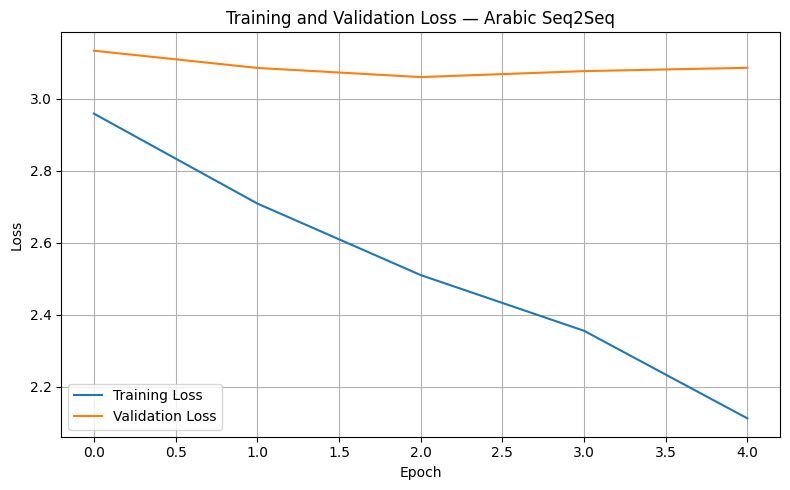

In [42]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df['loss'],     label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss — Arabic Seq2Seq')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 18. Word Lookup Dictionaries + Token ID Validation
Before building inference models, we verify that `sostoken` and `eostoken` received valid vocabulary IDs during tokenizer fitting. If either check fails here, the error message will tell you exactly what went wrong rather than letting it silently corrupt inference.


In [43]:
word_index = tokenizer.word_index
index_word = {idx: word for word, idx in tokenizer.word_index.items() if idx < vocab_size}

# Safe fetch with explicit validation
start_id = word_index.get(START_TOKEN)
end_id   = word_index.get(END_TOKEN)

if start_id is None:
    raise ValueError(f"'{START_TOKEN}' not found in vocabulary. "
                     "Ensure decoder_input column was included during tokenizer fitting (Cell 8).")
if end_id is None:
    raise ValueError(f"'{END_TOKEN}' not found in vocabulary. "
                     "Ensure decoder_target column was included during tokenizer fitting (Cell 8).")
if start_id >= vocab_size:
    raise ValueError(f"'{START_TOKEN}' has id {start_id} >= vocab_size {vocab_size}. "
                     "It will be treated as OOV during inference — increase VOCAB_SIZE.")
if end_id >= vocab_size:
    raise ValueError(f"'{END_TOKEN}' has id {end_id} >= vocab_size {vocab_size}. "
                     "It will be treated as OOV during inference — increase VOCAB_SIZE.")

print('sostoken id :', start_id)
print('eostoken id :', end_id)
print('Both special tokens are safely within vocabulary. Ready for inference.')

sostoken id : 5
eostoken id : 6
Both special tokens are safely within vocabulary. Ready for inference.


## 19. Encoder Inference Model
At inference time we need to run the encoder and decoder **separately**. The encoder runs once per article and returns the context vectors used at every decoder step.


In [44]:
encoder_model = Model(
    encoder_inputs,
    [encoder_outputs, state_h, state_c],
    name='encoder_model'
)

print('Encoder inference model ready.')

Encoder inference model ready.


## 20. Decoder Inference Model
The decoder inference model receives **one token at a time**, along with the previous LSTM states and all encoder outputs. It returns the next token probability distribution and updated states.

> **Why separate models?** During training the full summary sequence is fed at once (teacher forcing). At inference we must generate token-by-token since each token depends on the previous prediction.


In [45]:
decoder_single_input  = Input(shape=(1,),                          name='decoder_single_input')
decoder_state_h       = Input(shape=(LATENT_DIM * 2,),             name='decoder_state_h')
decoder_state_c       = Input(shape=(LATENT_DIM * 2,),             name='decoder_state_c')
encoder_outputs_input = Input(shape=(MAX_ART_LEN, LATENT_DIM * 2), name='encoder_outputs_input')

decoder_single_emb = encoder_embedding(decoder_single_input)  # reuse encoder_embedding

decoder_single_output, next_h, next_c = decoder_lstm(
    decoder_single_emb,
    initial_state=[decoder_state_h, decoder_state_c]
)

single_attention = attention_layer(
    [decoder_single_output, encoder_outputs_input],
    use_causal_mask=False
)

single_decoder_context = Concatenate(axis=-1)([decoder_single_output, single_attention])
single_word_probs      = decoder_dense(single_decoder_context)

decoder_model = Model(
    [decoder_single_input, encoder_outputs_input, decoder_state_h, decoder_state_c],
    [single_word_probs, next_h, next_c],
    name='decoder_model'
)

print('Decoder inference model ready.')

Decoder inference model ready.


## 21. Summary Generation (Greedy Decoding)
The `generate_summary` function implements **greedy decoding** with a **repetition guard**:

1. Run the encoder on the article → get context vectors
2. Feed `sostoken` as the first decoder input
3. At each step: pick the highest-probability token, append it, feed it back
4. Stop when `eostoken` is predicted, token id is 0 (padding), or `MAX_SUM_LEN` steps reached
5. **Repetition guard:** if any word appears more than `max_repeat` times, stop early — this prevents the common failure mode where seq2seq models loop on the same word indefinitely


In [46]:
def generate_summary(input_seq, max_repeat=3):
    enc_out, h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq    = np.array([[start_id]])
    summary_words = []
    word_count    = {}

    for step in range(MAX_SUM_LEN):
        probs, h, c = decoder_model.predict([target_seq, enc_out, h, c], verbose=0)
        
        # Sort all tokens by probability, skip oov/special tokens
        token_probs = probs[0, -1, :]
        sorted_ids  = np.argsort(token_probs)[::-1]  # highest prob first
        
        next_id   = None
        next_word = None
        for candidate_id in sorted_ids[:20]:  # check top 20 candidates
            candidate_word = index_word.get(int(candidate_id), '')
            if candidate_word in ('', OOV_TOKEN, START_TOKEN, END_TOKEN):
                continue
            if int(candidate_id) == 0:
                continue
            next_id   = int(candidate_id)
            next_word = candidate_word
            break

        # No valid word found in top 20 -> stop
        if next_id is None:
            break

        if next_id == end_id and step >= 3:
            break

        word_count[next_word] = word_count.get(next_word, 0) + 1
        if word_count[next_word] > max_repeat:
            continue

        summary_words.append(next_word)
        target_seq = np.array([[next_id]])

    return ' '.join(summary_words)

print('generate_summary function defined.')

generate_summary function defined.


## 22. Qualitative Check — Sample Summaries
Inspect 5 test examples to get a feel for the model's output before running formal ROUGE evaluation.


In [47]:
for i in range(min(5, len(test_df))):
    generated = generate_summary(x_test[i:i+1])

    print(f'--- Example {i+1} ---')
    print('Article (first 300 chars):')
    print(test_df.iloc[i]['article_clean'][:300])
    print()
    print('Reference Summary:')
    print(test_df.iloc[i]['summary_clean'])
    print()
    print('Generated Summary:')
    print(generated if generated else '[empty — model may need more training]')
    print('=' * 80)
    print()

--- Example 1 ---
Article (first 300 chars):
مءتمر اسلامي مثير للجدل، عقد كولونيا مطلع العام الجديد ، طالبت حكومه ولايه الراين ويستفاليا، اكبر ولايه المانيه عدد السكان، فيهم المسلمين، اتحاد المساجد التركيه الالماني ديتيب بالتحرر التبعيه للدوله التركيه والابتعاد تاثيرها المباشر وقال متحدث باسم حكومه الراين ويستفاليا لصحيفه غنرال انتسايغر بون عد

Reference Summary:
مءتمر مثير للجدل حول الاسلام المانيا عقد مدينه كولونيا مطلع الشهر الجاري، طالبت حكومه الراين ويستفاليا اتحاد المساجد الاسلاميه التركيه ديتيب بالتحرر التبعيه للدوله التركيه والخروج نفوذها المباشر

Generated Summary:
اثار قرار البرلمان الالماني حول مشروع قانون مثير للجدل يسمح بدخول المسلمين المانيا الي جانب دستور جديد حول العالم الاسلامي وفي سياق متصل اكد وزير الداخليه الالماني ان المسلمين المانيا قريبا جدا قريبا جدا ان يكون مجرد شيء جدا لهذه الازمه السياسيه والاقتصاديه والاجتماعيه والاقتصاديه والاجتماعيه والاقتصاديه والاجتماعيه

--- Example 2 ---
Article (first 300 chars):
قال المتحدث باسم الحكومه الالمانيه، شتيفن زايبرت، اليوم

## 23. ROUGE Evaluation

**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) measures overlap between generated and reference summaries:

| Metric | Measures |
|--------|----------|
| ROUGE-1 | Unigram (single word) overlap |
| ROUGE-2 | Bigram (two-word phrase) overlap |
| ROUGE-L | Longest Common Subsequence — captures sentence-level structure |

**Important fix:** `rouge-score`'s internal tokenizer does not handle Arabic Unicode correctly and returns 0 for all scores. The fix is to pre-tokenize Arabic text ourselves using simple whitespace splitting before passing to the scorer — Arabic words are already whitespace-separated after cleaning.


In [48]:
from collections import Counter

def get_ngrams(tokens, n):
    return Counter(zip(*[tokens[i:] for i in range(n)]))

def rouge_n(reference, prediction, n):
    ref_tokens  = reference.split()
    pred_tokens = prediction.split()
    
    ref_ngrams  = get_ngrams(ref_tokens,  n)
    pred_ngrams = get_ngrams(pred_tokens, n)
    
    overlap = sum((pred_ngrams & ref_ngrams).values())
    
    precision = overlap / max(sum(pred_ngrams.values()), 1)
    recall    = overlap / max(sum(ref_ngrams.values()),  1)
    
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)  # F1

def rouge_l(reference, prediction):
    ref_tokens  = reference.split()
    pred_tokens = prediction.split()
    r, p        = len(ref_tokens), len(pred_tokens)
    
    # LCS dynamic programming
    dp = [[0] * (p + 1) for _ in range(r + 1)]
    for i in range(1, r + 1):
        for j in range(1, p + 1):
            if ref_tokens[i-1] == pred_tokens[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    lcs = dp[r][p]
    
    precision = lcs / max(p, 1)
    recall    = lcs / max(r, 1)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

# --- Evaluation loop ---
eval_size = min(100, len(test_df))
results   = []
print(f'Evaluating on {eval_size} test samples...')

for i in range(eval_size):
    reference  = test_df.iloc[i]['summary_clean'].strip()
    prediction = generate_summary(x_test[i:i+1]).strip()

    if not prediction:
        results.append({'reference': reference, 'prediction': prediction,
                        'rouge1_f': 0.0, 'rouge2_f': 0.0, 'rougeL_f': 0.0})
        continue

    results.append({
        'reference':  reference,
        'prediction': prediction,
        'rouge1_f':   rouge_n(reference, prediction, 1),
        'rouge2_f':   rouge_n(reference, prediction, 2),
        'rougeL_f':   rouge_l(reference, prediction)
    })

rouge_df = pd.DataFrame(results)
print('ROUGE-1 F1:', round(rouge_df['rouge1_f'].mean(), 4))
print('ROUGE-2 F1:', round(rouge_df['rouge2_f'].mean(), 4))
print('ROUGE-L F1:', round(rouge_df['rougeL_f'].mean(), 4))
rouge_df.head(10)

Evaluating on 100 test samples...
ROUGE-1 F1: 0.0828
ROUGE-2 F1: 0.0135
ROUGE-L F1: 0.0695


,reference,prediction,rouge1_f,rouge2_f,rougeL_f
0,مءتمر مثير للجدل حول الاسلام المانيا عقد مدينه...,اثار قرار البرلمان الالماني حول مشروع قانون مث...,0.105263,0.027027,0.105263
1,اعلن مرشح الحزب الاشتراكي الديمقراطي للمنافسه ...,رغم ان يكون سياسه اللجوء المانيا الا ان الماني...,0.085106,0.044444,0.085106
2,يسود التفاءل حزب العداله والتنميه الاسلامي الم...,رغم ان حزب النهضه الاسلامي الحاكم تونس علي حسا...,0.188679,0.000000,0.150943
3,راغب عياد، راءد تصوير الحياه المصريه الريفيه ب...,مشاركه قويه مصر علي مستوي الخط الفني وطرح تحدي...,0.055556,0.000000,0.055556
4,تمت، عشيه اليوم الجمعه ، احاله محام علي الداءر...,وقد تم نقل المصاب الي المستشفي الجامعي سهلول ا...,0.028986,0.000000,0.028986
5,رفع المدعي العام بامبيرغ جنوب المانيا دعوي بته...,رغم ان يكون بامكان الناس ان يكون سوي شخص فقط ا...,0.000000,0.000000,0.000000
6,اصدرت واشنطن وبروكسل بيانا مشتركا اعربتا قلقهم...,يري خبراء ان الرءيس المصري السابق حسني مبارك ع...,0.058824,0.000000,0.029412
7,يوم وصفه الفلسطينيون بالتاريخي، قررت المحكمه ا...,اصدرت المحكمه الجناءيه الدوليه لاهاي علي خلفيه...,0.163934,0.067797,0.131148
8,يبدو ان ادراه نادي دورتموند مشغوله الايام بالب...,يبدو ان دورتموند الالماني السابق مسعود اوزيل ي...,0.125000,0.032258,0.125000
9,وكانت الحمله شعار نلمو المليار,وقال ان الهدف الاول الاول نوعه سنه فقط ان يتم ...,0.000000,0.000000,0.000000


In [50]:
#Checking percentage of empty predictions

non_empty = rouge_df[rouge_df['prediction'].str.strip() != '']
print(f"Non-empty predictions: {len(non_empty)} / {len(rouge_df)} ({100*len(non_empty)/len(rouge_df):.1f}%)")
print('ROUGE-1 (non-empty):', round(non_empty['rouge1_f'].mean(), 4))
print('ROUGE-2 (non-empty):', round(non_empty['rouge2_f'].mean(), 4))
print('ROUGE-L (non-empty):', round(non_empty['rougeL_f'].mean(), 4))

Non-empty predictions: 100 / 100 (100.0%)
ROUGE-1 (non-empty): 0.0828
ROUGE-2 (non-empty): 0.0135
ROUGE-L (non-empty): 0.0695


## 24. Save Model, Tokenizer, and Results


In [49]:
model.save('arabic_seq2seq_attention_model.keras')

with open('arabic_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

rouge_df.to_csv('rouge_results.csv', index=False, encoding='utf-8-sig')

print('Saved:')
print('  arabic_seq2seq_attention_model.keras')
print('  arabic_tokenizer.pkl')
print('  rouge_results.csv')

Saved:
  arabic_seq2seq_attention_model.keras
  arabic_tokenizer.pkl
  rouge_results.csv
